# LangGraph Memory 示範

這份 notebook 使用 `MemorySaver` 儲存 LangGraph checkpoints。只要使用相同的 `thread_id`，Graph 就能載入最近的 checkpoint，讓 LLM 讀到先前訊息；不同的 `thread_id` 則會擁有彼此獨立的狀態歷史。

> Checkpoint 是某個時間點的完整 State 快照；Memory 是應用程式利用這些 checkpoints 延續對話後呈現出的能力。

## 1. Import libraries

In [12]:
import os

from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END

## 2. 建立 LLM

請先在系統環境變數中設定 `OPENAI_API_KEY`。如果課程環境使用自訂 API endpoint，也可以設定 `OPENAI_BASE_URL`。

In [13]:
llm_options = {
    "api_key": os.environ["OPENAI_API_KEY"],
    "model": os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    "temperature": 0.0,
}

# 如果有設定自訂 endpoint，就將它加入 ChatOpenAI 的參數。
if os.getenv("OPENAI_BASE_URL"):
    llm_options["base_url"] = os.getenv("OPENAI_BASE_URL")

llm = ChatOpenAI(**llm_options)

## 3. 建立具有記憶功能的 LangGraph

`MessagesState` 會累積訊息；`MemorySaver` 則依照 `thread_id` 保存每次執行後的 checkpoint。

In [14]:
def chatbot(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


workflow = StateGraph(MessagesState)
workflow.add_node("chatbot", chatbot)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

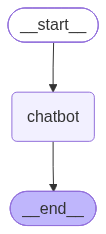

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 4. 準備對話函式

每次只傳入最新問題。過去的訊息不需要由我們手動重傳，checkpointer 會根據 `thread_id` 自動取回。

In [16]:
def ask(question: str, thread_id: str = "demo-user") -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)]},
        config=config,
    )
    answer = result["messages"][-1].content
    print(f"You: {question}\nAI: {answer}")
    return answer

## 5. 測試：讓 LLM 記住先前說過的內容

In [17]:
ask("請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。", thread_id="conversation-1")

You: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
AI: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！


'好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！'

In [18]:
# 沒有再次提供名字與寶可夢，模型仍可從同一個 thread 的記憶回答。
ask("我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？", thread_id="conversation-1")

You: 我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？
AI: 你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！


'你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！'

## 6. 查看記憶體中的訊息

可以直接讀取目前 checkpoint，確認 `conversation-1` 已保存完整對話。

In [19]:
config_1 = {"configurable": {"thread_id": "conversation-1"}}
current_state = graph.get_state(config_1)

for message in current_state.values["messages"]:
    print(f"{message.type}: {message.content}")

human: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
ai: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！
human: 我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？
ai: 你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！


## 7. 查看目前 Checkpoint 的資訊

`graph.get_state(config)` 回傳的不是單純字典，而是 `StateSnapshot`。除了 State values，還包含 checkpoint ID、建立時間、下一個節點與 metadata。

In [20]:
checkpoint_id = current_state.config["configurable"]["checkpoint_id"]

print("Checkpoint ID:", checkpoint_id)
print("Created at:   ", current_state.created_at)
print("Next nodes:   ", current_state.next)
print("Metadata:     ", current_state.metadata)
print("Message count:", len(current_state.values["messages"]))

Checkpoint ID: 1f1b887d-d6df-6587-8004-20128d9ce76f
Created at:    2026-09-25T02:21:50.026268+00:00
Next nodes:    ()
Metadata:      {'source': 'loop', 'step': 4, 'parents': {}}
Message count: 4


`next=()` 表示這個 checkpoint 已經執行到 Graph 的終點。如果流程停在某個 interrupt，`next` 會顯示等待執行的節點。

## 8. 列出同一個 Thread 的 Checkpoint History

`get_state_history()` 會從最新到最舊列出 checkpoints。一次 `graph.invoke()` 可能產生多個 checkpoint，因為 LangGraph 會在輸入與節點完成等不同階段保存 State。

In [21]:
history = list(graph.get_state_history(config_1))

print(f"Total checkpoints: {len(history)}\n")

for index, snapshot in enumerate(history, start=1):
    snapshot_config = snapshot.config["configurable"]
    messages = snapshot.values.get("messages", [])
    message_count = len(messages)

    print(f"Checkpoint {index}")
    print("  id:           ", snapshot_config.get("checkpoint_id"))
    print("  created_at:   ", snapshot.created_at)
    print("  step:         ", snapshot.metadata.get("step"))
    print("  source:       ", snapshot.metadata.get("source"))
    print("  next:         ", snapshot.next)
    print("  message_count:", message_count)
    print("  messages:")

    if not messages:
        print("    (empty)")
    else:
        for message_index, message in enumerate(messages, start=1):
            content = str(message.content).replace("\n", " ")
            preview = content if len(content) <= 120 else content[:117] + "..."
            print(
                f"    [{message_index}] {message.type}: {preview}"
            )
    print("---")

Total checkpoints: 6

Checkpoint 1
  id:            1f1b887d-d6df-6587-8004-20128d9ce76f
  created_at:    2026-09-25T02:21:50.026268+00:00
  step:          4
  source:        loop
  next:          ()
  message_count: 4
  messages:
    [1] human: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
    [2] ai: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！
    [3] human: 我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？
    [4] ai: 你的名字是小明，你最喜歡的寶可夢是皮卡丘！如果還有其他想聊的，隨時告訴我！
---
Checkpoint 2
  id:            1f1b887d-ca0b-6e4b-8003-60b1791bd47d
  created_at:    2026-09-25T02:21:48.681365+00:00
  step:          3
  source:        loop
  next:          ('chatbot',)
  message_count: 3
  messages:
    [1] human: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
    [2] ai: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！
    [3] human: 我剛才說我的名字是什麼？最喜歡的寶可夢又是誰？
---
Checkpoint 3
  id:            1f1b887d-c99d-6d3d-8002-6272f051c99e
  created_at:    2026-09-25T02:21:48.636282+00:00
  step:          2
  source:        input
  next:          ('__start__',)
  message_count: 2
  messages

## 9. 讀取舊的 Checkpoint

每個歷史 `StateSnapshot.config` 都包含自己的 `checkpoint_id`。把該 config 傳給 `get_state()`，就能讀回當時的完整 State。

下面找出最早一個已完成、且包含訊息的 checkpoint。它應只包含第一輪對話，而目前 checkpoint 已包含兩輪對話。

In [22]:
completed_checkpoints = [
    snapshot
    for snapshot in history
    if not snapshot.next and snapshot.values.get("messages")
]

oldest_completed_checkpoint = completed_checkpoints[-1]
historical_state = graph.get_state(oldest_completed_checkpoint.config)

print("Historical checkpoint ID:")
print(historical_state.config["configurable"]["checkpoint_id"])
print("\nMessages stored at that time:")

for message in historical_state.values["messages"]:
    print(f"{message.type}: {message.content}")

Historical checkpoint ID:
1f1b887d-c980-6b93-8001-4f75001ce536

Messages stored at that time:
human: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
ai: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！


In [23]:
print("Historical message count:", len(historical_state.values["messages"]))
print("Current message count:   ", len(current_state.values["messages"]))

Historical message count: 2
Current message count:    4


這就是 checkpoint 的核心用途：除了載入最新狀態來延續工作，也能檢查先前狀態，支援除錯、稽核、人工介入與 time-travel 等進階功能。

## 9A. 從歷史 Snapshot 建立新分支

將新輸入和歷史 snapshot 的 config 一起傳給 `graph.invoke()`，LangGraph 就會以該 snapshot 的 State 為起點建立新分支。

原本較新的 checkpoint 不會被刪除，因此之後仍可分別查看：

- `branch_start`：新分支開始前的歷史狀態。
- `original_latest`：建立分支之前，原路線的最新狀態。
- `new_branch`：從舊 snapshot 加入新問題後的新狀態。

In [24]:
# 先保留建立分支前的兩個 StateSnapshot。
branch_start_state = historical_state
original_latest_state = current_state

# 使用舊 checkpoint 的 config，加上新訊息，建立另一條對話分支。
graph.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "從這個時間點開始，我最喜歡的寶可夢改成傑尼龜，"
                    "請記住這項變更。"
                )
            )
        ]
    },
    config=branch_start_state.config,
)

# get_state_history() 由新到舊排列，因此第一筆就是剛建立的分支終點。
new_branch_state = next(graph.get_state_history(config_1))

snapshots_to_view = {
    "branch_start": branch_start_state,
    "original_latest": original_latest_state,
    "new_branch": new_branch_state,
}

print("Available views:", list(snapshots_to_view))
for name, snapshot in snapshots_to_view.items():
    print(
        f"- {name}: "
        f"{snapshot.config['configurable']['checkpoint_id']} "
        f"({len(snapshot.values.get('messages', []))} messages)"
    )

Available views: ['branch_start', 'original_latest', 'new_branch']
- branch_start: 1f1b887d-c980-6b93-8001-4f75001ce536 (2 messages)
- original_latest: 1f1b887d-d6df-6587-8004-20128d9ce76f (4 messages)
- new_branch: 1f1b887d-e8ad-6fee-8004-ee7ba333a399 (4 messages)


### 選擇要查看的 Snapshot

修改 `selected_view` 後重新執行下一格，就能在三個狀態之間切換，不需要重新呼叫 LLM。

In [25]:
# 可改成：branch_start、original_latest 或 new_branch
selected_view = "new_branch"

if selected_view not in snapshots_to_view:
    raise ValueError(
        f"Unknown view: {selected_view}. "
        f"Choose from {list(snapshots_to_view)}"
    )

selected_snapshot = snapshots_to_view[selected_view]
selected_checkpoint_id = selected_snapshot.config["configurable"]["checkpoint_id"]

print("Selected view: ", selected_view)
print("Checkpoint ID:", selected_checkpoint_id)
print("Created at:   ", selected_snapshot.created_at)
print("Next nodes:   ", selected_snapshot.next)
print("Messages:")

for message_index, message in enumerate(
    selected_snapshot.values.get("messages", []),
    start=1,
):
    print(f"  [{message_index}] {message.type}: {message.content}")

Selected view:  new_branch
Checkpoint ID: 1f1b887d-e8ad-6fee-8004-ee7ba333a399
Created at:    2026-09-25T02:21:51.893491+00:00
Next nodes:    ()
Messages:
  [1] human: 請記住：我的名字是小明，我最喜歡的寶可夢是皮卡丘。
  [2] ai: 好的，小明！我會記住你最喜歡的寶可夢是皮卡丘。如果你有任何問題或想聊的話，隨時告訴我！
  [3] human: 從這個時間點開始，我最喜歡的寶可夢改成傑尼龜，請記住這項變更。
  [4] ai: 好的，小明！我會記住你現在最喜歡的寶可夢是傑尼龜。如果還有其他想要更改或分享的，隨時告訴我！


`original_latest` 與 `new_branch` 都可以繼續透過各自保存的 snapshot config 讀取。分支是在 checkpoint history 中形成的關係，不會覆寫或刪除原路線。

## 10. 對照：不同 thread 不共享 Checkpoints

下面改用全新的 `conversation-2`。因為它沒有前面的 checkpoint，模型應該不知道使用者的名字與喜好。

In [26]:
ask("我的名字是什麼？我最喜歡哪一隻寶可夢？", thread_id="conversation-2")

You: 我的名字是什麼？我最喜歡哪一隻寶可夢？
AI: 抱歉，我無法知道你的名字或你最喜歡的寶可夢。如果你願意，可以告訴我你的名字和喜歡的寶可夢，我會很高興地和你聊聊！


'抱歉，我無法知道你的名字或你最喜歡的寶可夢。如果你願意，可以告訴我你的名字和喜歡的寶可夢，我會很高興地和你聊聊！'

## 重點整理

- Checkpoint 是特定時間點的完整 State 快照，不只是聊天文字。
- `MemorySaver` 是 checkpointer，負責寫入與讀取 checkpoints。
- 相同 `thread_id`：載入最近 checkpoint，延續先前訊息。
- `checkpoint_id`：指定同一 thread 中的某一個歷史狀態。
- `get_state()`：讀取目前或指定 checkpoint。
- `get_state_history()`：查看同一 thread 的狀態演變。
- 不同 `thread_id`：各自保存 checkpoint history，隔離不同使用者或對話。
- `MemorySaver` 只保存在目前 Python 程序的記憶體中；kernel 重啟後 checkpoints 就會消失。正式系統可改用資料庫型 checkpointer。